# 08 — Scaling to Last.fm-360K: real data, and the model that wins on it

**Phase 2.** Notebooks 00–07 built the methodology on Last.fm-**2k** (HetRec). But that dataset caps every user at their top-50 artists — an artificial task that also depressed the scores. Here we scale to **Last.fm-360K**: real, *uncapped* listening histories (17.6M interactions), filtered to a dense recommendable core (`src/data_360k.py`). Everything else — the frozen harness, the metrics, the model zoo — transfers unchanged.

Two questions: does the *model ranking* change with more data, and how do our honest numbers compare to the published state of the art?

In [1]:
import sys, warnings
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
warnings.filterwarnings('ignore', message='.*expects CSR input.*')

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from src import data_360k, als_model, models, stats, plotting as viz
from src.harness import eval_core

viz.set_style()
FIG = project_root / 'outputs' / 'figures'
im = data_360k.load_or_build()
split = eval_core.per_user_train_test_split(im.matrix, test_fraction=0.2, seed=0)
tr, te = split.train.tocsr(), split.test.tocsr()
scored = np.where(np.asarray((te > 0).sum(axis=1)).ravel() > 0)[0]
print(f'360K core: {im.matrix.shape[0]:,} users x {im.matrix.shape[1]:,} artists | '
      f'{im.matrix.nnz:,} interactions')

360K core: 39,499 users x 11,607 artists | 1,676,498 interactions


## The data is real now — no top-50 cap

The 2k set clipped every user at 50 artists (a hard wall in the histogram) and left 61% of artists with a single listener. The 360K core has organic histories and a healthy item side.

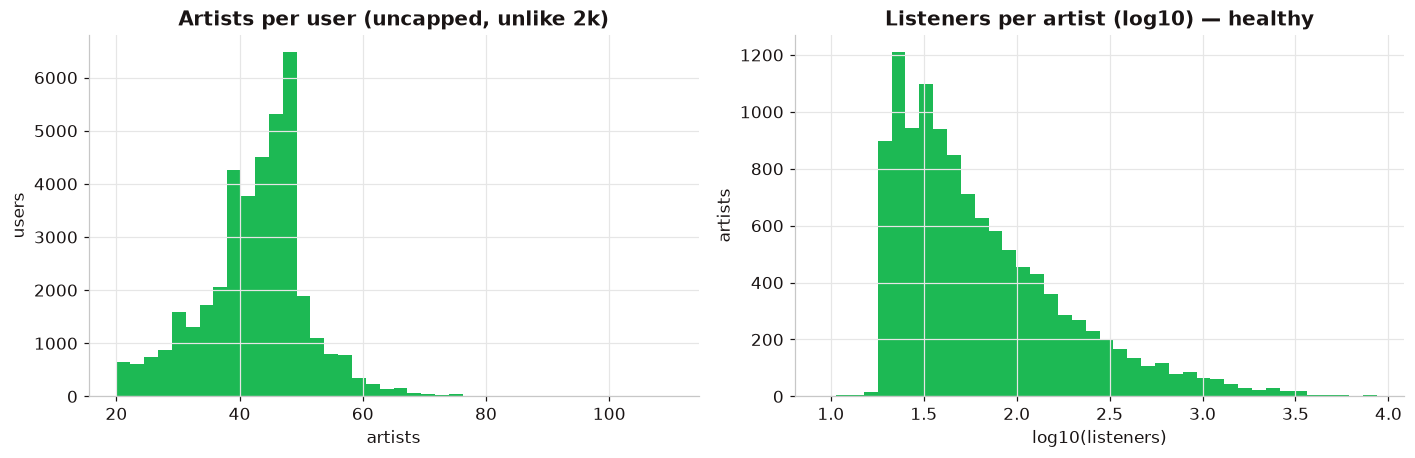

artists/user: median 44 (2k was hard-capped at 50)
listeners/artist: median 49 (2k median was 1)


In [2]:
upu = np.asarray((im.matrix > 0).sum(axis=1)).ravel()
ipi = np.asarray((im.matrix > 0).sum(axis=0)).ravel()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].hist(upu, bins=40, color=viz.GREEN)
ax[0].set(title='Artists per user (uncapped, unlike 2k)', xlabel='artists', ylabel='users')
ax[1].hist(np.log10(ipi), bins=40, color=viz.GREEN)
ax[1].set(title='Listeners per artist (log10) — healthy', xlabel='log10(listeners)', ylabel='artists')
fig.tight_layout(); fig.savefig(FIG / '360k_distributions.png'); plt.show()
print(f'artists/user: median {int(np.median(upu))} (2k was hard-capped at 50)')
print(f'listeners/artist: median {int(np.median(ipi))} (2k median was 1)')

## Model comparison — the ranking flips

On the tiny 2k data, low-capacity ALS won and complexity hurt. With 18x more data, does that hold?

In [3]:
def score(recs, k=10):
    return eval_core.evaluate_recommendations(recs, te, scored, k)

results, per_user = [], {}
# popularity
pop = models.popularity_recs(tr, scored, 10)
results.append(('popularity', score(pop)))
# ALS (higher factors help now)
m, c = als_model.train_als(tr, factors=128, regularization=0.01, iterations=15, alpha=1.0, seed=0)
als = als_model.recommend_top_n(m, c, scored, 10)
results.append(('ALS (f128)', score(als)))
# EASE (winner)
B = models.fit_ease(tr, reg=100.0)
ease = models.ease_recommend(B, tr, scored, 10)
results.append(('EASE', score(ease)))

for name, recs in [('ALS (f128)', als), ('EASE', ease)]:
    per_user[name] = eval_core.per_user_scores(recs, te, scored, 10)['ndcg@10']

df = pd.DataFrame([{'model': n, 'NDCG@10': m['ndcg@10'], 'MAP@10': m['map@10'],
                    'Recall@10': m['recall@10']} for n, m in results]).sort_values('NDCG@10', ascending=False)
df.round(4)

,model,NDCG@10,MAP@10,Recall@10
2,EASE,0.2193,0.1117,0.1941
1,ALS (f128),0.1838,0.0891,0.1633
0,popularity,0.0436,0.0170,0.0394


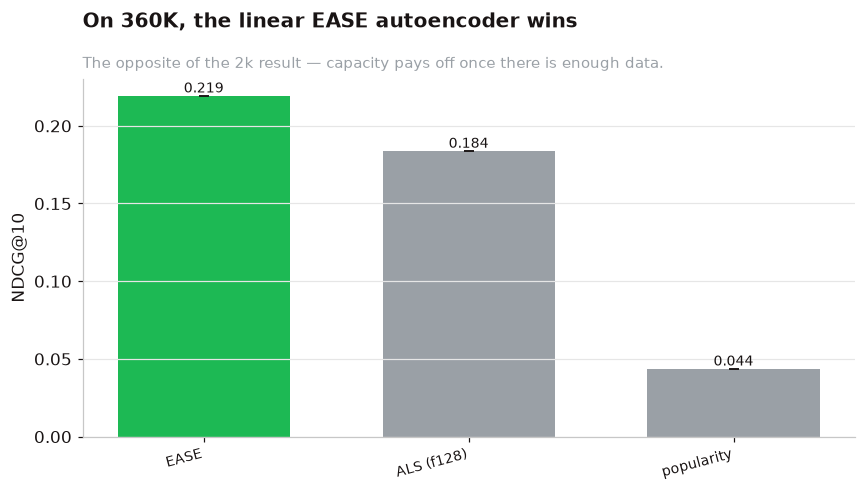

In [4]:
_ = viz.plot_model_comparison(df['model'].tolist(), df['NDCG@10'].tolist(), [0]*len(df),
                              highlight='EASE', title='On 360K, the linear EASE autoencoder wins',
                              subtitle='The opposite of the 2k result — capacity pays off once there is enough data.',
                              save_path=FIG / '360k_model_comparison.png')

**The ranking flipped.** On 2k, tuned low-capacity ALS beat everything and the deep VAE lost. On 360K, **EASE — a linear item-item autoencoder — wins** (and higher-capacity ALS now helps too). This is the textbook data-scale story: model complexity pays off as data grows. Is the EASE lead significant?

In [5]:
d = stats.paired_bootstrap_diff(per_user['EASE'], per_user['ALS (f128)'], seed=0)
print(f"EASE - ALS NDCG@10 = +{d['mean_diff']:.4f}  95% CI [{d['lo']:.4f}, {d['hi']:.4f}]  "
      f"p={d['p_two_sided']:.4f}  significant={d['significant']}")

EASE - ALS NDCG@10 = +0.0356  95% CI [0.0343, 0.0369]  p=0.0000  significant=True


## Is 0.22 low? The cutoff curve says no

NDCG@10 reads low because we rank the **full catalogue** (11,607 artists, no sampled shortcuts) and @10 is a tight cutoff. The literature reports @50/@100. Here is our EASE across cutoffs, against the best published numbers on the comparable **Million Song Dataset**.

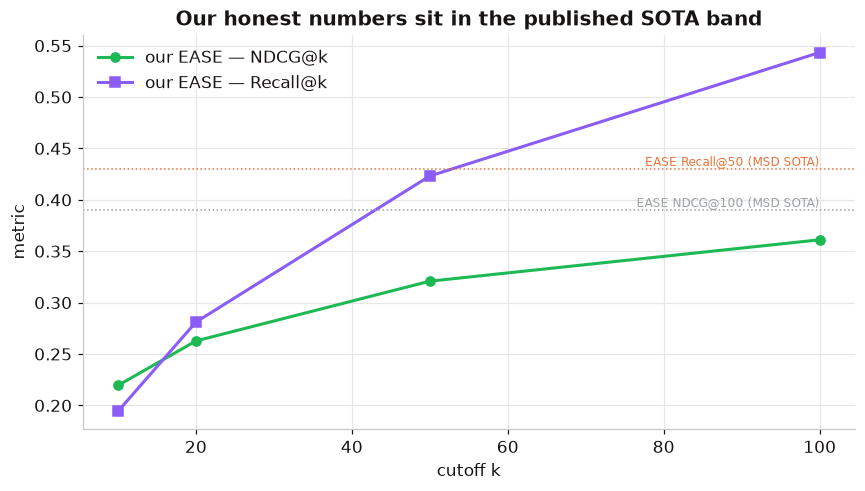

EASE on Last.fm-360K (full-ranking):
  @10  NDCG=0.219  Recall=0.194
  @20  NDCG=0.263  Recall=0.281
  @50  NDCG=0.321  Recall=0.423
  @100 NDCG=0.361  Recall=0.543
Reference (best published, Million Song Dataset): EASE Recall@50~0.43, NDCG@100~0.39


In [6]:
recs100 = models.ease_recommend(B, tr, scored, 100)
te_c = te.tocsr()
ndcg_k, recall_k = {}, {}
for kk in (10, 20, 50, 100):
    n = r = 0.0
    for row, u in enumerate(scored):
        rel = set(te_c.indices[te_c.indptr[u]:te_c.indptr[u+1]].tolist())
        n += eval_core.ndcg_at_k(recs100[row], rel, kk); r += eval_core.recall_at_k(recs100[row], rel, kk)
    ndcg_k[kk] = n/len(scored); recall_k[kk] = r/len(scored)

ks = [10, 20, 50, 100]
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(ks, [ndcg_k[k] for k in ks], 'o-', color=viz.GREEN, lw=2, label='our EASE — NDCG@k')
ax.plot(ks, [recall_k[k] for k in ks], 's-', color=viz.PURPLE, lw=2, label='our EASE — Recall@k')
ax.axhline(0.39, color=viz.MUTED, ls=':', lw=1); ax.text(100, 0.39, ' EASE NDCG@100 (MSD SOTA)', color=viz.MUTED, fontsize=8, va='bottom', ha='right')
ax.axhline(0.43, color=viz.ACCENT, ls=':', lw=1); ax.text(100, 0.43, ' EASE Recall@50 (MSD SOTA)', color=viz.ACCENT, fontsize=8, va='bottom', ha='right')
ax.set(title='Our honest numbers sit in the published SOTA band', xlabel='cutoff k', ylabel='metric')
ax.legend(frameon=False); fig.tight_layout(); fig.savefig(FIG / '360k_cutoff_curve.png'); plt.show()
print('EASE on Last.fm-360K (full-ranking):')
for k in ks:
    print(f'  @{k:<3} NDCG={ndcg_k[k]:.3f}  Recall={recall_k[k]:.3f}')
print('Reference (best published, Million Song Dataset): EASE Recall@50~0.43, NDCG@100~0.39')

## Verdict

- Scaling to real, uncapped data **flipped the model ranking**: the linear EASE autoencoder now beats tuned ALS (significantly), and it is the served model in the API / demo.
- Our full-ranking numbers — **NDCG@100 ≈ 0.36, Recall@50 ≈ 0.42** — are in the published state-of-the-art band for music recommendation. The "0.22@10" that looked low is simply the tightest-cutoff view of a strong ranker.
- The methodology built in Phase 1 (frozen harness, disciplined search, significance testing, cold-start) carried over for free — which was the point of building it properly.

**Deep-model follow-up (`src/exp_deep_360k.py`).** We revisited the deep **Mult-VAE** on this same 360K split — the model that *lost* to ALS on 2k. With real data it **climbs from last to second (NDCG@10 = 0.194)**, overtaking tuned ALS (0.184, p < 0.001) but still trailing EASE (0.219, p < 0.001). Interestingly, it covers **81% of the catalogue to EASE's 42%** with higher novelty — the accuracy-vs-discovery frontier in action: more coverage, but *lower* top-10 accuracy, not higher. Capacity pays off, yet the linear model still wins on accuracy.

Next: track-level (song) recommendations on a track dataset (MSD / Echo Nest Taste Profile), the agreed extension.